In [51]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})
%matplotlib widget

In [52]:
# Paths
data_folder = os.path.abspath('../data')
figure_save_folder = os.path.abspath('../figures/CKII_pooled')
os.makedirs(figure_save_folder, exist_ok=True)
print(f'Data folder: {data_folder}')
print(f'Figures will be saved to: {figure_save_folder}')

# Thresholds for CS+ classification
CS_RATE_THRESHOLD = 0.2
CS_PEAK_RATE_THRESHOLD = 0.4

# ===================== GLOBAL PLOTTING PARAMETERS =====================
SMOOTH_WINDOW = 200
PLOT_TRIALS = True
TRIAL_ALPHA = 0.15
TRIAL_LINEWIDTH = 0.4
THETA_YLIM = (-0.05, 0.2)
SLOW_YLIM = (-0.05, 0.15)
FR_YLIM_SCALE = 1.1
SS_CS_YLIM_SCALE = 1.2
xlim = [-4, 4]

print(f'\n=== Plotting Parameters ===')
print(f'Smoothing window: {SMOOTH_WINDOW} frames')
print(f'Plot individual trials: {PLOT_TRIALS}')
print(f'Trial alpha: {TRIAL_ALPHA}, linewidth: {TRIAL_LINEWIDTH}')
print(f'Theta ylim: {THETA_YLIM}, Slow ylim: {SLOW_YLIM}')
print(f'FR ylim scale: {FR_YLIM_SCALE}, SS/CS ylim scale: {SS_CS_YLIM_SCALE}')

ckii_folders = [
    'CKII_pAce21_PR_20250806',
    'CKII_pAce38_PX_20251126',
    'CKII_pAce45_PX_20260118',
]

def get_deleted_cells(data_folder, folders, snr_threshold=3.5, bad_frac_threshold=0.9):
    deleted_set = set()
    for folder in folders:
        merged_path = os.path.join(data_folder, folder, 'merged_aligned_data_CS.pkl')
        if not os.path.exists(merged_path):
            continue
        with open(merged_path, 'rb') as f:
            merged_data = pickle.load(f)
        SNR_interpolated = merged_data.get('SNR_interpolated', [])
        for cell_idx in range(len(SNR_interpolated)):
            snr_vals = np.asarray(SNR_interpolated[cell_idx])
            if snr_vals.ndim == 0:
                deleted_set.add((folder, cell_idx))
                continue
            bad_mask = snr_vals < snr_threshold
            bad_frac = np.mean(bad_mask)
            if bad_frac > bad_frac_threshold:
                deleted_set.add((folder, cell_idx))
    return deleted_set

deleted_cells = get_deleted_cells(data_folder, ckii_folders)
print(f'Found {len(deleted_cells)} truly deleted cells (>90% bad SNR frames).')

# Load pooled stats and filter deleted cells
all_dfs = []
for folder in ckii_folders:
    pkl_path = os.path.join(data_folder, folder, 'pooled_stats.pkl')
    if os.path.exists(pkl_path):
        df = pd.read_pickle(pkl_path)
        df['session'] = folder
        all_dfs.append(df)
        print(f'Loaded {len(df)} cells from {folder}')
    else:
        print(f'Missing: {pkl_path}')

if len(all_dfs) == 0:
    raise RuntimeError('No pooled_stats.pkl found.')

df_all_raw = pd.concat(all_dfs, ignore_index=True)
valid_mask = ~df_all_raw.apply(lambda row: (row['session'], row['cell_idx']) in deleted_cells, axis=1)
df_all = df_all_raw[valid_mask].copy().reset_index(drop=True)
df_pc = df_all[df_all['is_place_cell'] == True].copy()

peak_all = df_pc['peak_rate_all'].values
peak_cs = df_pc['peak_rate_cs'].values
with np.errstate(divide='ignore', invalid='ignore'):
    normalized_cs_peak = np.where(peak_all > 0, peak_cs / peak_all, 0.0)
is_cs_plc = (normalized_cs_peak >= CS_RATE_THRESHOLD) & (peak_cs >= CS_PEAK_RATE_THRESHOLD)

df_pc['is_cs_plc'] = is_cs_plc
df_pc['normalized_cs_peak'] = normalized_cs_peak
df_all.loc[df_all['is_place_cell'] == True, 'is_cs_plc'] = False
df_all.loc[df_pc.index, 'is_cs_plc'] = is_cs_plc
df_all.loc[df_pc.index, 'normalized_cs_peak'] = normalized_cs_peak

print(f'Total place cells: {len(df_pc)} | CS+ PLCs: {int(is_cs_plc.sum())} | CS- PLCs: {int((~is_cs_plc).sum())}')

# Load pf_centered_trial_data
pf_centered_data_by_session = {}
time_rel_by_session = {}
center_by_pf_position_by_session = {}

for folder in ckii_folders:
    pkl_path = os.path.join(data_folder, folder, 'pf_centered_trial_data.pkl')
    if os.path.exists(pkl_path):
        with open(pkl_path, 'rb') as f:
            d = pickle.load(f)
        pf_centered_data_by_session[folder] = d.get('pf_centered_data', [])
        time_rel_by_session[folder] = np.asarray(d.get('time_rel', []), dtype=float)
        center_by_pf_position_by_session[folder] = d.get('center_by_pf_position', False)
        n_cells = len(pf_centered_data_by_session[folder])
        n_with_data = sum(1 for x in pf_centered_data_by_session[folder] if x is not None)
        print(f'Loaded pf_centered_trial_data from {folder}: {n_with_data}/{n_cells} cells with data')
    else:
        print(f'Missing: {pkl_path}')

# ===================== Helper functions =====================
def _fmt_two_decimals(x, _):
    return f"{x:.2f}".rstrip("0").rstrip(".")

def _smooth_boxcar(trace, win=5):
    arr = np.asarray(trace, dtype=float)
    if win <= 1:
        return arr
    kernel = np.ones(win, dtype=float)
    valid = np.isfinite(arr).astype(float)
    arr_filled = np.where(np.isfinite(arr), arr, 0.0)
    smoothed = np.convolve(arr_filled, kernel, mode="same")
    counts = np.convolve(valid, kernel, mode="same")
    with np.errstate(invalid="ignore", divide="ignore"):
        smoothed = np.where(counts > 0, smoothed / counts, np.nan)
    return smoothed

def collect_category_data(is_cs_plc_value):
    time_rel_ref = None
    entries = []
    for _, row in df_all[df_all['is_place_cell'] == True].iterrows():
        if bool(row.get('is_cs_plc', False)) != is_cs_plc_value:
            continue
        session = row['session']
        cell_idx = int(row['cell_idx'])
        pf_data_list = pf_centered_data_by_session.get(session, None)
        if pf_data_list is None or cell_idx >= len(pf_data_list):
            continue
        cell_data = pf_data_list[cell_idx]
        if cell_data is None:
            continue
        time_rel = time_rel_by_session.get(session, None)
        if time_rel is None or len(time_rel) == 0:
            continue
        if time_rel_ref is None:
            time_rel_ref = time_rel
        if len(time_rel_ref) != len(time_rel):
            continue
        entries.append({'session': session, 'cell_idx': cell_idx, 'data': cell_data})
    return time_rel_ref, entries

# ===================== Heatmap plotting =====================
def plot_single_cell_heatmap(entry_data, time_rel, smooth_window=0, out_path=None, show_plot=True,
                              fr_vmax_scale=0.8, theta_vlim=(0, 0.5), slow_vlim=(-0.25, 0.25),
                              fig_width=4.5, trial_height=0.06, xlim=[-2, 2]):
    """
    Plot heatmaps with consistent aspect ratio across all panels.
    
    Each column may have different numbers of trials, so heights vary.
    Y-limits are set dynamically per column to avoid white space.
    Y-ticks show only first (1) and last trial number for each column.
    
    Parameters:
    -----------
    trial_height : float
        Height per trial in inches (controls aspect ratio)
    fig_width : float
        Total figure width in inches
    """
    from matplotlib.gridspec import GridSpec
    
    cell_data = entry_data['data']
    session = entry_data['session']
    cell_idx = entry_data['cell_idx']
    
    all_data = cell_data.get('all', {})
    cw_data = cell_data.get('cw', {})
    ccw_data = cell_data.get('ccw', {})
    
    def _get_stack(data, key):
        stack = data.get(key)
        if stack is None:
            return None
        stack = np.asarray(stack, dtype=float)
        if stack.ndim != 2 or stack.shape[1] != len(time_rel):
            return None
        if smooth_window > 1:
            smoothed = np.zeros_like(stack)
            for i in range(stack.shape[0]):
                smoothed[i] = _smooth_boxcar(stack[i], smooth_window)
            return smoothed
        return stack
    
    row_labels = ['FR', 'SS FR', 'CS FR', 'θ amp.', 'Slow Vm']
    stack_keys = ['rate_stack', 'ss_rate_stack', 'cs_rate_stack', 'theta_stack', 'slow_stack']
    cmaps = ['Greys', 'BuGn', 'YlOrBr', 'Blues', 'Reds']
    directions = [all_data, cw_data, ccw_data]
    dir_titles = ['All', 'CW', 'CCW']
    
    row_vmax = [0.0] * 5
    row_vmin = [0.0] * 5
    all_stacks = [[None]*3 for _ in range(5)]
    
    # Collect all stacks and compute row-wise vmin/vmax
    for col, dir_data in enumerate(directions):
        for row, key in enumerate(stack_keys):
            stack = _get_stack(dir_data, key)
            all_stacks[row][col] = stack
            if stack is not None and stack.size > 0 and row < 3:
                row_vmax[row] = max(row_vmax[row], np.nanmax(stack))
    
    for row in range(3):
        row_vmin[row] = 0
        row_vmax[row] = row_vmax[row] * fr_vmax_scale if row_vmax[row] > 0 else 1
    row_vmin[3], row_vmax[3] = theta_vlim
    row_vmin[4], row_vmax[4] = slow_vlim
    
    # Get trial counts for each column (use max across rows for that column)
    col_trials = []
    for col in range(3):
        max_trials = 1
        for row in range(5):
            stack = all_stacks[row][col]
            if stack is not None:
                max_trials = max(max_trials, stack.shape[0])
        col_trials.append(max_trials)
    
    # Find max trials across all columns for figure height calculation
    max_trials_all = max(col_trials)
    
    # Calculate figure height based on trial counts and number of rows
    row_spacing = 0.15  # inches between rows
    title_space = 0.3   # inches for title
    xlabel_space = 0.3  # inches for x-axis label
    fig_height = 5 * (max_trials_all * trial_height) + 4 * row_spacing + title_space + xlabel_space
    
    # Create figure with GridSpec
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    # Width ratios: 3 heatmap columns + 1 narrow colorbar column
    gs = GridSpec(5, 4, figure=fig, width_ratios=[1, 1, 1, 0.05], 
                  wspace=0.15, hspace=0.35)
    
    axes = np.empty((5, 3), dtype=object)
    cbar_axes = [None] * 5
    
    # Create axes
    for row in range(5):
        for col in range(3):
            axes[row, col] = fig.add_subplot(gs[row, col])
        cbar_axes[row] = fig.add_subplot(gs[row, 3])
    
    # Store image handles for colorbars
    row_images = [None] * 5
    
    # Time range for consistent x-axis
    time_range = time_rel[-1] - time_rel[0]
    
    for col, (dir_data, dir_title) in enumerate(zip(directions, dir_titles)):
        n_trials = dir_data.get('n_trials', 0)
        n_total = dir_data.get('n_total_trials', 0)
        
        for row, (key, cmap, label) in enumerate(zip(stack_keys, cmaps, row_labels)):
            ax = axes[row, col]
            stack = all_stacks[row][col]
            
            if stack is None or stack.size == 0:
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, 
                       ha='center', va='center', fontsize=6)
                ax.set_xlim(time_rel[0], time_rel[-1])
                ax.set_ylim(col_trials[col] + 0.5, 0.5)
            else:
                if row == 4:
                    cmap_use = 'RdBu_r'
                elif row == 3:
                    cmap_use = 'Blues'
                else:
                    cmap_use = cmap
                
                vmin, vmax = row_vmin[row], row_vmax[row]
                actual_trials = stack.shape[0]
                
                # Plot heatmap with extent matching actual data
                im = ax.imshow(stack, aspect='auto', origin='upper',
                              extent=[time_rel[0], time_rel[-1], actual_trials + 0.5, 0.5],
                              cmap=cmap_use, vmin=vmin, vmax=vmax)
                
                ax.axvline(0, color='k', linewidth=0.25, linestyle='--', alpha=0.5)
                
                # Set y-axis limit dynamically per column (no white space)
                ax.set_ylim(col_trials[col] + 0.5, 0.5)
                
                if row_images[row] is None:
                    row_images[row] = im
            
            # Labels and titles
            if row == 0:
                ax.set_title(f'{dir_title}\n({n_trials}/{n_total})', fontsize=6)
            if col == 0:
                ax.set_ylabel(label, fontsize=6)
            if row == 4:
                ax.set_xlabel('Time (s)', fontsize=6)
            else:
                ax.set_xticklabels([])

            # Set y-ticks: only first (1) and last trial number
            max_trial = col_trials[col]
            if max_trial > 1:
                ax.set_yticks([1, max_trial])
            else:
                ax.set_yticks([1])

            ax.tick_params(labelsize=5)
    
    for ax in axes.flat:
        ax.set_xlim(xlim)
    
    # Add colorbars
    for row in range(5):
        if row_images[row] is not None:
            cbar = fig.colorbar(row_images[row], cax=cbar_axes[row])
            cbar.ax.tick_params(labelsize=4)
        else:
            cbar_axes[row].axis('off')
    

    plt.tight_layout()
    
    if out_path is not None:
        fig.savefig(out_path, dpi=300)
        print(f'Saved: {out_path}')
    if show_plot:
        plt.show()
    else:
        plt.close(fig)
    return fig

# ===================== Individual cell plotting =====================
def plot_single_cell_3col(entry_data, time_rel, smooth_window=100, plot_trials=True, 
                          trial_alpha=0.2, trial_linewidth=0.5, out_path=None, show_plot=True,
                          theta_ylim=None, slow_ylim=None, fr_ylim_scale=1.2, ss_cs_ylim_scale=1.2):
    cell_data = entry_data['data']
    session = entry_data['session']
    cell_idx = entry_data['cell_idx']
    
    all_data = cell_data.get('all', {})
    cw_data = cell_data.get('cw', {})
    ccw_data = cell_data.get('ccw', {})
    
    def _prep_data(data, ref_time_rel, do_smooth=True):
        if data is None:
            return None
        data = np.asarray(data, dtype=float)
        if len(data) != len(ref_time_rel):
            return None
        if do_smooth:
            data = _smooth_boxcar(data, smooth_window)
        return data
    
    theta = _prep_data(all_data.get('theta_mean'), time_rel)
    slow = _prep_data(all_data.get('slow_mean'), time_rel)
    rate = _prep_data(all_data.get('rate_mean'), time_rel)
    ss_rate = _prep_data(all_data.get('ss_rate_mean'), time_rel)
    cs_rate = _prep_data(all_data.get('cs_rate_mean'), time_rel)
    
    theta_cw = _prep_data(cw_data.get('theta_mean'), time_rel)
    slow_cw = _prep_data(cw_data.get('slow_mean'), time_rel)
    rate_cw = _prep_data(cw_data.get('rate_mean'), time_rel)
    ss_rate_cw = _prep_data(cw_data.get('ss_rate_mean'), time_rel)
    cs_rate_cw = _prep_data(cw_data.get('cs_rate_mean'), time_rel)
    
    theta_ccw = _prep_data(ccw_data.get('theta_mean'), time_rel)
    slow_ccw = _prep_data(ccw_data.get('slow_mean'), time_rel)
    rate_ccw = _prep_data(ccw_data.get('rate_mean'), time_rel)
    ss_rate_ccw = _prep_data(ccw_data.get('ss_rate_mean'), time_rel)
    cs_rate_ccw = _prep_data(ccw_data.get('cs_rate_mean'), time_rel)
    
    n_valid_all = all_data.get('n_trials', 0)
    n_total_all = all_data.get('n_total_trials', 0)
    n_valid_cw = cw_data.get('n_trials', 0)
    n_total_cw = cw_data.get('n_total_trials', 0)
    n_valid_ccw = ccw_data.get('n_trials', 0)
    n_total_ccw = ccw_data.get('n_total_trials', 0)
    
    fr_max = 0
    for rt in [rate, rate_cw, rate_ccw]:
        if rt is not None:
            fr_max = max(fr_max, np.nanmax(rt))
    fr_ylim_auto = (0, fr_max * fr_ylim_scale) if fr_max > 0 else None
    
    ss_cs_max = 0
    for rt in [ss_rate, cs_rate, ss_rate_cw, cs_rate_cw, ss_rate_ccw, cs_rate_ccw]:
        if rt is not None:
            ss_cs_max = max(ss_cs_max, np.nanmax(rt))
    ss_cs_ylim_auto = (0, ss_cs_max * ss_cs_ylim_scale) if ss_cs_max > 0 else None
    
    fig1 = plt.figure(figsize=(6, 3.5))
    axes1 = np.empty((4, 3), dtype=object)
    for col in range(3):
        sharey_ax = axes1[3, 0] if col > 0 else None
        axes1[3, col] = fig1.add_subplot(4, 3, 3 * 3 + col + 1, sharey=sharey_ax)
    for row in range(3):
        for col in range(3):
            sharey_ax = axes1[row, 0] if col > 0 else None
            sharex_ax = axes1[3, col]
            axes1[row, col] = fig1.add_subplot(4, 3, row * 3 + col + 1, sharex=sharex_ax, sharey=sharey_ax)
    
    def _plot_fig1_column(axes_col, t_rel, th, sl, rt, ss_rt, cs_rt, dir_data, title_suffix, n_valid, n_total):
        if plot_trials and dir_data.get('n_trials', 0) > 0:
            n_trials = dir_data['n_trials']
            rate_stack = dir_data.get('rate_stack')
            ss_rate_stack = dir_data.get('ss_rate_stack')
            cs_rate_stack = dir_data.get('cs_rate_stack')
            theta_stack = dir_data.get('theta_stack')
            slow_stack = dir_data.get('slow_stack')
            for i in range(n_trials):
                if rate_stack is not None and i < len(rate_stack):
                    trial_rate = _smooth_boxcar(rate_stack[i], smooth_window)
                    axes_col[0].plot(t_rel, trial_rate, color='#555555', linewidth=trial_linewidth, alpha=trial_alpha)
                if ss_rate_stack is not None and cs_rate_stack is not None and i < len(ss_rate_stack):
                    trial_ss = _smooth_boxcar(ss_rate_stack[i], smooth_window)
                    trial_cs = _smooth_boxcar(cs_rate_stack[i], smooth_window)
                    axes_col[1].plot(t_rel, trial_cs, color='#EE9B00', linewidth=trial_linewidth, alpha=trial_alpha)
                    axes_col[1].plot(t_rel, trial_ss, color='#026C80', linewidth=trial_linewidth, alpha=trial_alpha)
                if theta_stack is not None and i < len(theta_stack):
                    trial_theta = _smooth_boxcar(theta_stack[i], smooth_window)
                    axes_col[2].plot(t_rel, trial_theta, color='blue', linewidth=trial_linewidth, alpha=trial_alpha)
                if slow_stack is not None and i < len(slow_stack):
                    trial_slow = _smooth_boxcar(slow_stack[i], smooth_window)
                    axes_col[3].plot(t_rel, trial_slow, color='red', linewidth=trial_linewidth, alpha=trial_alpha)
        if rt is not None:
            axes_col[0].plot(t_rel, rt, color='#555555', linewidth=1.0)
        axes_col[0].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        if cs_rt is not None:
            axes_col[1].plot(t_rel, cs_rt, color='#EE9B00', linewidth=1.0)
        if ss_rt is not None:
            axes_col[1].plot(t_rel, ss_rt, color='#026C80', linewidth=1.0)
        axes_col[1].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        if th is not None:
            axes_col[2].plot(t_rel, th, color='blue', linewidth=1.0)
        axes_col[2].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        if sl is not None:
            axes_col[3].plot(t_rel, sl, color='red', linewidth=1.0)
        axes_col[3].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        axes_col[3].axhline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        axes_col[0].set_title(f'{title_suffix}\n({n_valid}/{n_total} valid)', fontsize=6)
    
    _plot_fig1_column(axes1[:, 0], time_rel, theta, slow, rate, ss_rate, cs_rate, all_data, "All", n_valid_all, n_total_all)
    _plot_fig1_column(axes1[:, 1], time_rel, theta_cw, slow_cw, rate_cw, ss_rate_cw, cs_rate_cw, cw_data, "CW", n_valid_cw, n_total_cw)
    _plot_fig1_column(axes1[:, 2], time_rel, theta_ccw, slow_ccw, rate_ccw, ss_rate_ccw, cs_rate_ccw, ccw_data, "CCW", n_valid_ccw, n_total_ccw)
    
    axes1[0, 0].set_ylabel('FR', fontsize=6)
    axes1[1, 0].set_ylabel('SS/CS FR', fontsize=6)
    axes1[2, 0].set_ylabel('θ amp.\n(spk. height)', fontsize=6)
    axes1[3, 0].set_ylabel('Slow Vm\n(spk. height)', fontsize=6)
    for col in range(3):
        axes1[3, col].set_xlabel('Time from max FR (s)', fontsize=6)
    for row in range(3):
        for col in range(3):
            axes1[row, col].tick_params(labelbottom=False)
    if fr_ylim_auto is not None:
        for col in range(3):
            axes1[0, col].set_ylim(fr_ylim_auto)
    if ss_cs_ylim_auto is not None:
        for col in range(3):
            axes1[1, col].set_ylim(ss_cs_ylim_auto)
    if theta_ylim is not None:
        for col in range(3):
            axes1[2, col].set_ylim(theta_ylim)
    if slow_ylim is not None:
        for col in range(3):
            axes1[3, col].set_ylim(slow_ylim)
    for ax in axes1.flat:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=5)
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_two_decimals))
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig1.suptitle(f'{session} - Cell {cell_idx + 1}', fontsize=8)
    
    fig2, axes2 = plt.subplots(2, 3, figsize=(6, 2.0), sharey='row')
    def _plot_trial_rates(ax_all, ax_sscs, dir_data, show_legend=False):
        trial_data = dir_data.get('trial_data', None)
        if trial_data is None:
            ax_all.text(0.5, 0.5, 'No trial_data', transform=ax_all.transAxes, ha='center', va='center', fontsize=6)
            ax_sscs.text(0.5, 0.5, 'No trial_data', transform=ax_sscs.transAxes, ha='center', va='center', fontsize=6)
            return
        x = np.asarray(trial_data.get('epoch_start_sec', []), dtype=float)
        fr_all = np.asarray(trial_data.get('fr_all_hz', []), dtype=float)
        fr_ss = np.asarray(trial_data.get('fr_ss_hz', []), dtype=float)
        fr_cs = np.asarray(trial_data.get('fr_cs_hz', []), dtype=float)
        if x.size == 0:
            ax_all.text(0.5, 0.5, 'No trials', transform=ax_all.transAxes, ha='center', va='center', fontsize=6)
            ax_sscs.text(0.5, 0.5, 'No trials', transform=ax_sscs.transAxes, ha='center', va='center', fontsize=6)
            return
        mask = np.isfinite(x) & np.isfinite(fr_all)
        if not np.any(mask):
            return
        xs = x[mask]
        order = np.argsort(xs)
        xs = xs[order]
        ya = fr_all[mask][order]
        yss = fr_ss[mask][order]
        ycs = fr_cs[mask][order]
        ax_all.plot(xs, ya, color='#555555', linewidth=0.6, marker='o', markersize=2.0, alpha=0.9)
        ax_sscs.plot(xs, ycs, color='#EE9B00', linewidth=0.6, marker='o', markersize=2.0, alpha=0.9, label='CS')
        ax_sscs.plot(xs, yss, color='#026C80', linewidth=0.6, marker='o', markersize=2.0, alpha=0.9, label='SS')
        if show_legend:
            ax_sscs.legend(fontsize=5, frameon=False, loc='upper right')
    _plot_trial_rates(axes2[0, 0], axes2[1, 0], all_data, show_legend=True)
    _plot_trial_rates(axes2[0, 1], axes2[1, 1], cw_data)
    _plot_trial_rates(axes2[0, 2], axes2[1, 2], ccw_data)
    axes2[0, 0].set_title('All', fontsize=6)
    axes2[0, 1].set_title('CW', fontsize=6)
    axes2[0, 2].set_title('CCW', fontsize=6)
    axes2[0, 0].set_ylabel('Trial FR\n(Hz)', fontsize=6)
    axes2[1, 0].set_ylabel('Trial SS/CS\nFR (Hz)', fontsize=6)
    for col in range(3):
        axes2[1, col].set_xlabel('Trial start time (s)', fontsize=6)
    for ax in axes2.flat:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=5)
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_two_decimals))
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    fig2.suptitle(f'{session} - Cell {cell_idx + 1} (Trial rates)', fontsize=8)
    
    if out_path is not None:
        fig1.savefig(out_path, dpi=300)
        print(f'Saved: {out_path}')
        base, ext = os.path.splitext(out_path)
        out_path2 = f'{base}_trials{ext}'
        fig2.savefig(out_path2, dpi=300)
        print(f'Saved: {out_path2}')
    if show_plot:
        plt.show()
    else:
        plt.close(fig1)
        plt.close(fig2)
    return fig1, fig2

# ===================== Pooled average plotting =====================
def _stack_metric_from_entries(entries, direction, key, n_time, smooth_window=None):
    arrs = []
    for e in entries:
        data = e.get('data')
        if data is None:
            continue
        dir_data = data.get(direction, {})
        if dir_data.get('n_trials', 0) == 0:
            continue
        arr = dir_data.get(key)
        if arr is None or np.asarray(arr).size == 0:
            continue
        arr = np.asarray(arr, dtype=float)
        if arr.ndim == 2:
            mean_arr = np.nanmean(arr, axis=0)
        else:
            mean_arr = arr
        if mean_arr.size != n_time:
            continue
        if smooth_window is not None and smooth_window > 1:
            mean_arr = _smooth_boxcar(mean_arr, smooth_window)
        arrs.append(mean_arr)
    if len(arrs) == 0:
        return None
    return np.vstack(arrs)

def plot_pooled_category_3col(time_rel, entries, title, out_path=None,
                               smooth_window=None, plot_trials=True,
                               trial_alpha=0.2, trial_linewidth=0.5,
                               theta_ylim=None, slow_ylim=None,
                               fr_ylim_scale=1.2, ss_cs_ylim_scale=1.2, figsize=(4,2.5), xlim=[-2,2]):
    if time_rel is None or len(entries) == 0:
        print(f'No data to plot for {title}')
        return
    n_time = len(time_rel)
    
    def _mean_sem(arr):
        if arr is None or arr.size == 0:
            return None, None
        mean = np.nanmean(arr, axis=0)
        sem = np.nanstd(arr, axis=0) / np.sqrt(arr.shape[0])
        return mean, sem
    
    fig, axes = plt.subplots(4, 3, figsize=figsize, sharex='all', sharey='row')
    directions = ['all', 'cw', 'ccw']
    dir_titles = ['All', 'CW', 'CCW']
    
    zero_idx = np.argmin(np.abs(time_rel))
    
    all_rate_means = []
    all_ss_means = []
    all_cs_means = []
    
    for direction in directions:
        rate = _stack_metric_from_entries(entries, direction, 'rate_stack', n_time, smooth_window)
        ss_rate = _stack_metric_from_entries(entries, direction, 'ss_rate_stack', n_time, smooth_window)
        cs_rate = _stack_metric_from_entries(entries, direction, 'cs_rate_stack', n_time, smooth_window)
        # Normalize by this direction's own peak at time=0
        if rate is not None:
            peaks_this = rate[:, zero_idx]
            peaks_safe = np.where(peaks_this == 0, np.nan, peaks_this)
            rate_norm = rate / peaks_safe[:, np.newaxis]
        else:
            rate_norm = rate
        peaks_dir = rate[:, zero_idx] if rate is not None else None
        if ss_rate is not None and peaks_dir is not None:
            peaks_safe = np.where(peaks_dir == 0, np.nan, peaks_dir)
            ss_rate_norm = ss_rate / peaks_safe[:, np.newaxis]
        else:
            ss_rate_norm = ss_rate
        if cs_rate is not None and peaks_dir is not None:
            peaks_safe = np.where(peaks_dir == 0, np.nan, peaks_dir)
            cs_rate_norm = cs_rate / peaks_safe[:, np.newaxis]
        else:
            cs_rate_norm = cs_rate
        rate_mean, _ = _mean_sem(rate_norm)
        ss_mean, _ = _mean_sem(ss_rate_norm)
        cs_mean, _ = _mean_sem(cs_rate_norm)
        if rate_mean is not None:
            all_rate_means.append(rate_mean)
        if ss_mean is not None:
            all_ss_means.append(ss_mean)
        if cs_mean is not None:
            all_cs_means.append(cs_mean)
    
    fr_max = max([np.nanmax(rm) for rm in all_rate_means]) if all_rate_means else 0
    fr_ylim_auto = (0, fr_max * fr_ylim_scale) if fr_max > 0 else None
    ss_cs_max = max([np.nanmax(m) for m in all_ss_means + all_cs_means]) if (all_ss_means or all_cs_means) else 0
    ss_cs_ylim_auto = (0, ss_cs_max * ss_cs_ylim_scale) if ss_cs_max > 0 else None
    
    for col, (direction, dir_title) in enumerate(zip(directions, dir_titles)):
        rate = _stack_metric_from_entries(entries, direction, 'rate_stack', n_time, smooth_window)
        ss_rate = _stack_metric_from_entries(entries, direction, 'ss_rate_stack', n_time, smooth_window)
        cs_rate = _stack_metric_from_entries(entries, direction, 'cs_rate_stack', n_time, smooth_window)
        theta = _stack_metric_from_entries(entries, direction, 'theta_stack', n_time, smooth_window)
        slow = _stack_metric_from_entries(entries, direction, 'slow_stack', n_time, smooth_window)
        
        # Normalize by this direction's own peak at time=0
        if rate is not None:
            peaks_this = rate[:, zero_idx]
            peaks_safe = np.where(peaks_this == 0, np.nan, peaks_this)
            rate_norm = rate / peaks_safe[:, np.newaxis]
            # DEBUG: Check normalization
            vals_at_zero = rate_norm[:, zero_idx]
            print(f"DEBUG {direction}: zero_idx={zero_idx}, time_rel[zero_idx]={time_rel[zero_idx]:.4f}")
            print(f"  rate_norm[:5, zero_idx] = {vals_at_zero[:5]}")
            print(f"  All equal to 1? {np.allclose(vals_at_zero[np.isfinite(vals_at_zero)], 1.0)}")
        else:
            rate_norm = rate
        peaks_dir = rate[:, zero_idx] if rate is not None else None
        if ss_rate is not None and peaks_dir is not None:
            peaks_safe = np.where(peaks_dir == 0, np.nan, peaks_dir)
            ss_rate_norm = ss_rate / peaks_safe[:, np.newaxis]
        else:
            ss_rate_norm = ss_rate
        if cs_rate is not None and peaks_dir is not None:
            peaks_safe = np.where(peaks_dir == 0, np.nan, peaks_dir)
            cs_rate_norm = cs_rate / peaks_safe[:, np.newaxis]
        else:
            cs_rate_norm = cs_rate
        
        rate_mean, rate_sem = _mean_sem(rate_norm)
        ss_mean, ss_sem = _mean_sem(ss_rate_norm)
        cs_mean, cs_sem = _mean_sem(cs_rate_norm)
        theta_mean, theta_sem = _mean_sem(theta)
        slow_mean, slow_sem = _mean_sem(slow)
        n_cells = rate.shape[0] if rate is not None else 0
        
        if plot_trials and rate_norm is not None:
            for i in range(rate_norm.shape[0]):
                axes[0, col].plot(time_rel, rate_norm[i], color='#555555', linewidth=trial_linewidth, alpha=trial_alpha)
        if plot_trials and cs_rate_norm is not None:
            for i in range(cs_rate_norm.shape[0]):
                axes[1, col].plot(time_rel, cs_rate_norm[i], color='#EE9B00', linewidth=trial_linewidth, alpha=trial_alpha)
        if plot_trials and ss_rate_norm is not None:
            for i in range(ss_rate_norm.shape[0]):
                axes[1, col].plot(time_rel, ss_rate_norm[i], color='#026C80', linewidth=trial_linewidth, alpha=trial_alpha)
        if plot_trials and theta is not None:
            for i in range(theta.shape[0]):
                axes[2, col].plot(time_rel, theta[i], color='blue', linewidth=trial_linewidth, alpha=trial_alpha)
        if plot_trials and slow is not None:
            for i in range(slow.shape[0]):
                axes[3, col].plot(time_rel, slow[i], color='red', linewidth=trial_linewidth, alpha=trial_alpha)
        
        if rate_mean is not None:
            axes[0, col].plot(time_rel, rate_mean, color='#555555', linewidth=1.0)
            axes[0, col].fill_between(time_rel, rate_mean - rate_sem, rate_mean + rate_sem, color='#555555', alpha=0.2)
        axes[0, col].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        axes[0, col].set_title(f'{dir_title} (n={n_cells})', fontsize=6)
        
        if cs_mean is not None:
            axes[1, col].plot(time_rel, cs_mean, color='#EE9B00', linewidth=1.0, label='CS')
            axes[1, col].fill_between(time_rel, cs_mean - cs_sem, cs_mean + cs_sem, color='#EE9B00', alpha=0.2)
        if ss_mean is not None:
            axes[1, col].plot(time_rel, ss_mean, color='#026C80', linewidth=1.0, label='SS')
            axes[1, col].fill_between(time_rel, ss_mean - ss_sem, ss_mean + ss_sem, color='#026C80', alpha=0.2)
        axes[1, col].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        if col == 0:
            axes[1, col].legend(fontsize=5, frameon=False, loc='upper right')
        
        if theta_mean is not None:
            axes[2, col].plot(time_rel, theta_mean, color='blue', linewidth=1.0)
            axes[2, col].fill_between(time_rel, theta_mean - theta_sem, theta_mean + theta_sem, color='blue', alpha=0.2)
        axes[2, col].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        
        if slow_mean is not None:
            axes[3, col].plot(time_rel, slow_mean, color='red', linewidth=1.0)
            axes[3, col].fill_between(time_rel, slow_mean - slow_sem, slow_mean + slow_sem, color='red', alpha=0.2)
        axes[3, col].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        axes[3, col].axhline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
    
    axes[0, 0].set_ylabel('Norm. FR')
    axes[1, 0].set_ylabel('% in SS/CS')
    axes[2, 0].set_ylabel('Theta amp.')
    axes[3, 0].set_ylabel('Slow Vm')
    for col in range(3):
        axes[3, col].set_xlabel('Time from max FR (s)')
    
    if fr_ylim_auto is not None:
        for col in range(3):
            axes[0, col].set_ylim(fr_ylim_auto)
    if ss_cs_ylim_auto is not None:
        for col in range(3):
            axes[1, col].set_ylim(ss_cs_ylim_auto)
    if theta_ylim is not None:
        for col in range(3):
            axes[2, col].set_ylim(theta_ylim)
    if slow_ylim is not None:
        for col in range(3):
            axes[3, col].set_ylim(slow_ylim)
    
    for ax in axes.flat:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    fig.suptitle(f'{title}', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    for ax in axes.flat:
        ax.set_xlim(xlim)
    
    if out_path is not None:
        fig.savefig(out_path, dpi=300)
        print(f'Saved: {out_path}')
    plt.show()

# Collect data
time_rel_cs_plus, cs_plus_entries = collect_category_data(True)
time_rel_cs_minus, cs_minus_entries = collect_category_data(False)

print(f'\nCS+ PLCs: {len(cs_plus_entries)} cells with data')
print(f'CS- PLCs: {len(cs_minus_entries)} cells with data')


Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled

=== Plotting Parameters ===
Smoothing window: 200 frames
Plot individual trials: True
Trial alpha: 0.15, linewidth: 0.4
Theta ylim: (-0.05, 0.2), Slow ylim: (-0.05, 0.15)
FR ylim scale: 1.1, SS/CS ylim scale: 1.2
Found 3 truly deleted cells (>90% bad SNR frames).
Loaded 9 cells from CKII_pAce21_PR_20250806
Loaded 9 cells from CKII_pAce38_PX_20251126
Loaded 16 cells from CKII_pAce45_PX_20260118
Total place cells: 14 | CS+ PLCs: 9 | CS- PLCs: 5
Loaded pf_centered_trial_data from CKII_pAce21_PR_20250806: 2/9 cells with data
Loaded pf_centered_trial_data from CKII_pAce38_PX_20251126: 7/9 cells with data
Loaded pf_centered_trial_data from CKII_pAce45_PX_20260118: 4/16 cells with data

CS+ PLCs: 8 cells with data
CS- PLCs: 5 cells with data


In [53]:
##### Parameters cell - reference global parameters from Cell 1
# (Globals are: SMOOTH_WINDOW, PLOT_TRIALS, TRIAL_ALPHA, TRIAL_LINEWIDTH, THETA_YLIM, SLOW_YLIM, FR_YLIM_SCALE, SS_CS_YLIM_SCALE)
print(f'Using global parameters from Cell 1:')
print(f'  SMOOTH_WINDOW = {SMOOTH_WINDOW}')
print(f'  PLOT_TRIALS = {PLOT_TRIALS}')
print(f'  TRIAL_ALPHA = {TRIAL_ALPHA}')
print(f'  TRIAL_LINEWIDTH = {TRIAL_LINEWIDTH}')
print(f'  THETA_YLIM = {THETA_YLIM}')
print(f'  SLOW_YLIM = {SLOW_YLIM}')
print(f'  FR_YLIM_SCALE = {FR_YLIM_SCALE}')
print(f'  SS_CS_YLIM_SCALE = {SS_CS_YLIM_SCALE}')

Using global parameters from Cell 1:
  SMOOTH_WINDOW = 200
  PLOT_TRIALS = True
  TRIAL_ALPHA = 0.15
  TRIAL_LINEWIDTH = 0.4
  THETA_YLIM = (-0.05, 0.2)
  SLOW_YLIM = (-0.05, 0.15)
  FR_YLIM_SCALE = 1.1
  SS_CS_YLIM_SCALE = 1.2


# Individual cell plots for CS+ PLCs

Plotting 8 CS+ PLCs individual cell plots...
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce21_PR_20250806_Cell4_pf_centered.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce21_PR_20250806_Cell4_pf_centered_trials.svg


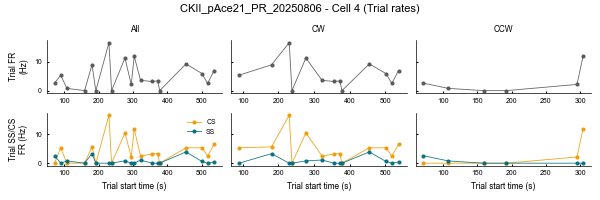

  [1/8] CKII_pAce21_PR_20250806 Cell 4
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce38_PX_20251126_Cell1_pf_centered.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce38_PX_20251126_Cell1_pf_centered_trials.svg


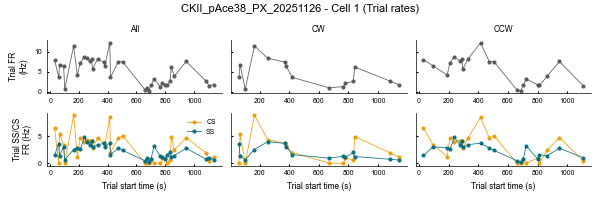

  [2/8] CKII_pAce38_PX_20251126 Cell 1
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce38_PX_20251126_Cell3_pf_centered.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce38_PX_20251126_Cell3_pf_centered_trials.svg


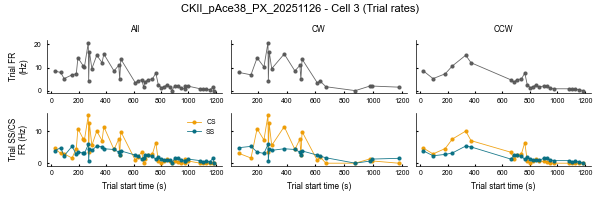

  [3/8] CKII_pAce38_PX_20251126 Cell 3
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce38_PX_20251126_Cell4_pf_centered.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce38_PX_20251126_Cell4_pf_centered_trials.svg


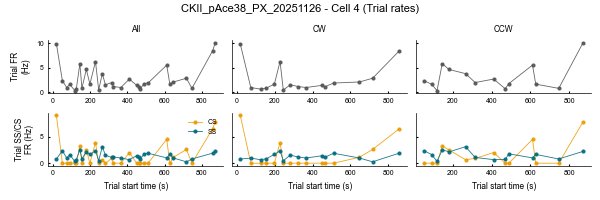

  [4/8] CKII_pAce38_PX_20251126 Cell 4
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce38_PX_20251126_Cell7_pf_centered.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce38_PX_20251126_Cell7_pf_centered_trials.svg


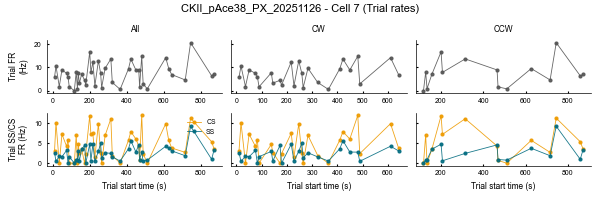

  [5/8] CKII_pAce38_PX_20251126 Cell 7
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce38_PX_20251126_Cell9_pf_centered.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce38_PX_20251126_Cell9_pf_centered_trials.svg


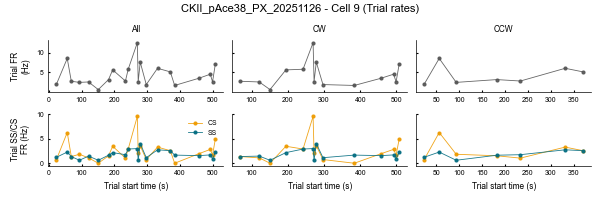

  [6/8] CKII_pAce38_PX_20251126 Cell 9
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce45_PX_20260118_Cell7_pf_centered.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce45_PX_20260118_Cell7_pf_centered_trials.svg


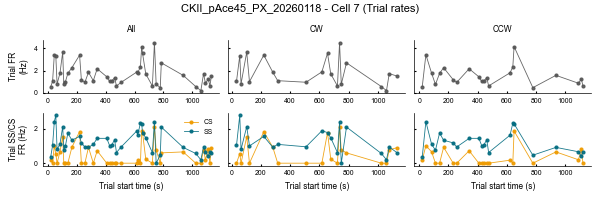

  [7/8] CKII_pAce45_PX_20260118 Cell 7
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce45_PX_20260118_Cell13_pf_centered.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual/CKII_pAce45_PX_20260118_Cell13_pf_centered_trials.svg


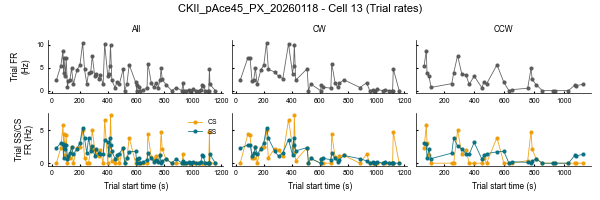

  [8/8] CKII_pAce45_PX_20260118 Cell 13

Saved individual CS+ PLC plots to: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_individual


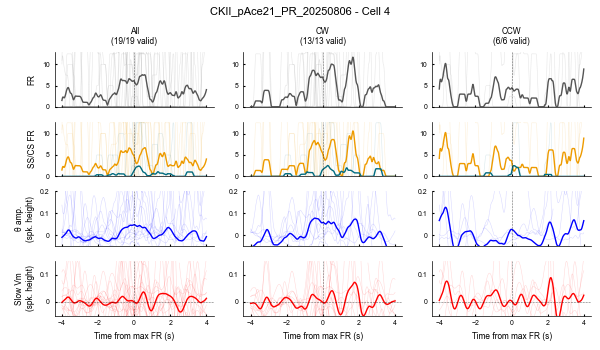

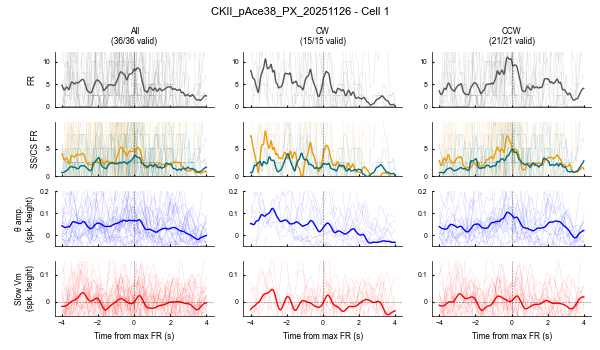

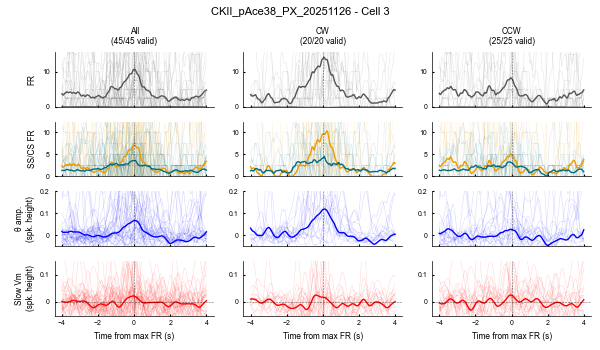

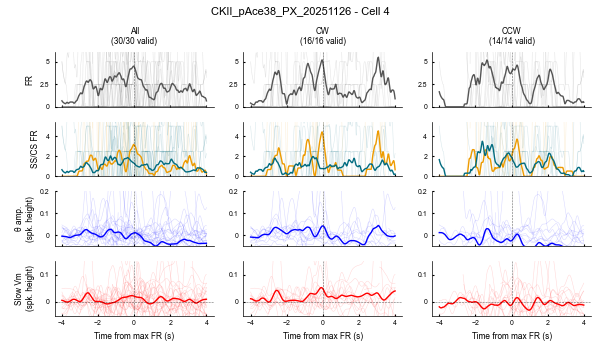

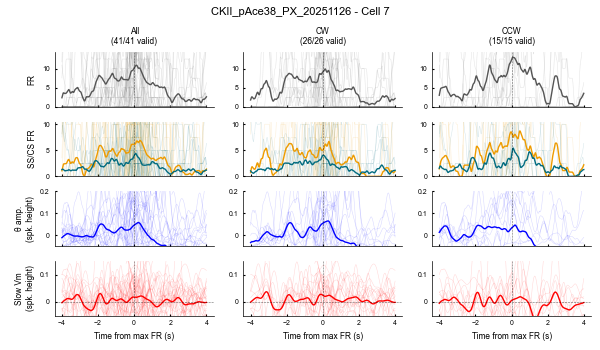

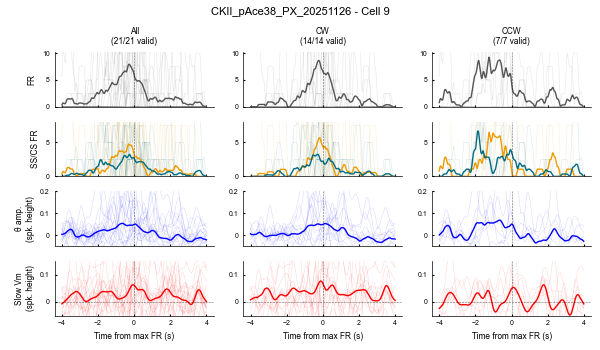

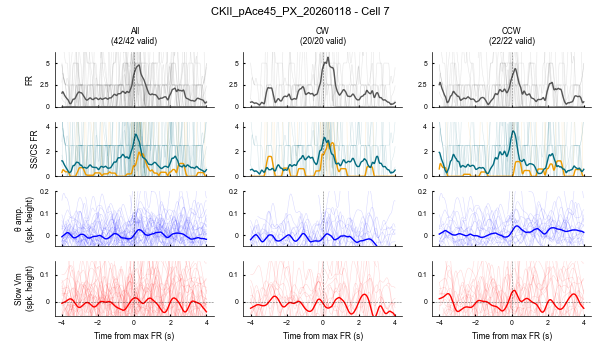

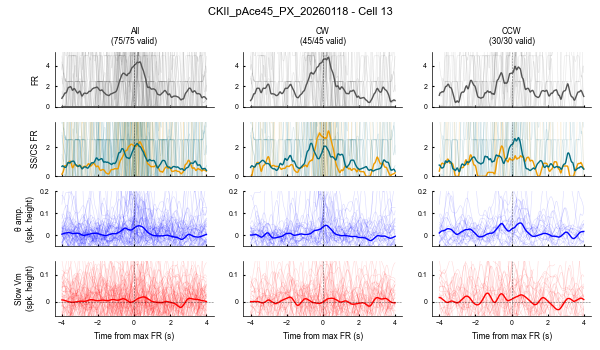

In [54]:
# ===================== CS+ PLCs: Individual cell plots =====================
print(f"Plotting {len(cs_plus_entries)} CS+ PLCs individual cell plots...")

cs_plus_save_folder = os.path.join(figure_save_folder, 'pf_centered_CSplus_individual')
os.makedirs(cs_plus_save_folder, exist_ok=True)

for i, entry_data in enumerate(cs_plus_entries):
    session = entry_data['session']
    cell_idx = entry_data['cell_idx']
    out_path = os.path.join(cs_plus_save_folder, f'{session}_Cell{cell_idx+1}_pf_centered.svg')
    
    plot_single_cell_3col(entry_data, time_rel_cs_plus, smooth_window=SMOOTH_WINDOW, plot_trials=PLOT_TRIALS,
                          trial_alpha=TRIAL_ALPHA, trial_linewidth=TRIAL_LINEWIDTH, out_path=out_path, show_plot=True,
                          theta_ylim=THETA_YLIM, slow_ylim=SLOW_YLIM,
                          fr_ylim_scale=FR_YLIM_SCALE, ss_cs_ylim_scale=SS_CS_YLIM_SCALE)
    print(f"  [{i+1}/{len(cs_plus_entries)}] {session} Cell {cell_idx+1}")

print(f"\nSaved individual CS+ PLC plots to: {cs_plus_save_folder}")

Plotting 8 CS+ PLCs individual cell heatmaps...


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce21_PR_20250806_Cell4_heatmap.svg


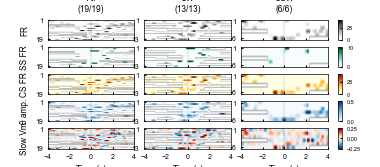

  [1/8] CKII_pAce21_PR_20250806 Cell 4


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce38_PX_20251126_Cell1_heatmap.svg


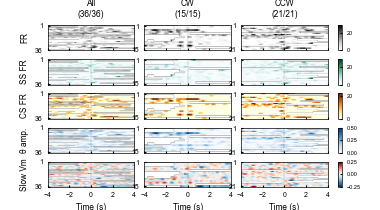

  [2/8] CKII_pAce38_PX_20251126 Cell 1


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce38_PX_20251126_Cell3_heatmap.svg


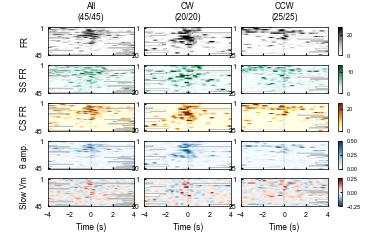

  [3/8] CKII_pAce38_PX_20251126 Cell 3


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce38_PX_20251126_Cell4_heatmap.svg


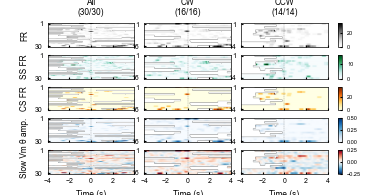

  [4/8] CKII_pAce38_PX_20251126 Cell 4


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce38_PX_20251126_Cell7_heatmap.svg


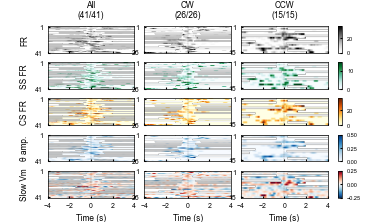

  [5/8] CKII_pAce38_PX_20251126 Cell 7


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce38_PX_20251126_Cell9_heatmap.svg


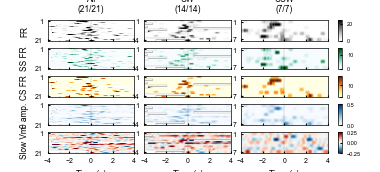

  [6/8] CKII_pAce38_PX_20251126 Cell 9


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce45_PX_20260118_Cell7_heatmap.svg


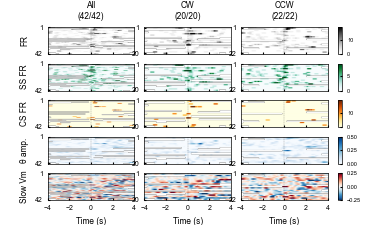

  [7/8] CKII_pAce45_PX_20260118 Cell 7


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce45_PX_20260118_Cell13_heatmap.svg


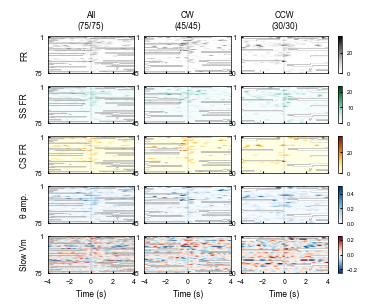

  [8/8] CKII_pAce45_PX_20260118 Cell 13

Saved individual CS+ PLC heatmaps to: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_heatmaps


In [55]:
# ===================== CS+ PLCs: Individual cell HEATMAP plots =====================
print(f"Plotting {len(cs_plus_entries)} CS+ PLCs individual cell heatmaps...")

cs_plus_heatmap_folder = os.path.join(figure_save_folder, 'pf_centered_CSplus_heatmaps')
os.makedirs(cs_plus_heatmap_folder, exist_ok=True)

for i, entry_data in enumerate(cs_plus_entries):
    session = entry_data['session']
    cell_idx = entry_data['cell_idx']
    out_path = os.path.join(cs_plus_heatmap_folder, f'{session}_Cell{cell_idx+1}_heatmap.svg')
    
    plot_single_cell_heatmap(entry_data, time_rel_cs_plus, smooth_window=SMOOTH_WINDOW, 
                              out_path=out_path, show_plot=True,
                              fr_vmax_scale=0.6, theta_vlim=(0, 0.5), slow_vlim=(-0.25, 0.25),fig_width=3.8, trial_height=0.005, xlim=xlim)
    print(f"  [{i+1}/{len(cs_plus_entries)}] {session} Cell {cell_idx+1}")

print(f"\nSaved individual CS+ PLC heatmaps to: {cs_plus_heatmap_folder}")

# Average plots for CS+ PLCs

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSplus_average.svg


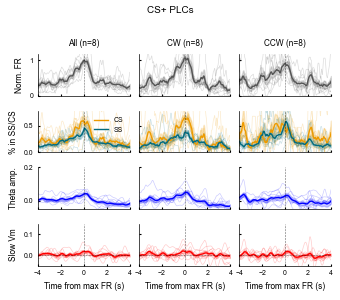

In [56]:
# ===================== CS+ PLCs: Pooled average (3-column: All/CW/CCW) =====================
out_cs_plus = os.path.join(figure_save_folder, 'pf_centered_CSplus_average.svg')
plot_pooled_category_3col(time_rel_cs_plus, cs_plus_entries, 'CS+ PLCs', out_cs_plus,
                          smooth_window=SMOOTH_WINDOW, plot_trials=PLOT_TRIALS,
                          trial_alpha=0.2, trial_linewidth=0.5,
                          theta_ylim=THETA_YLIM, slow_ylim=SLOW_YLIM,
                          fr_ylim_scale=FR_YLIM_SCALE, ss_cs_ylim_scale=SS_CS_YLIM_SCALE, figsize=(3.4, 3), xlim=xlim)

# Individual cell plots for CS- PLCs

Plotting 5 CS- PLCs individual cell plots...
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_individual/CKII_pAce21_PR_20250806_Cell1_pf_centered.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_individual/CKII_pAce21_PR_20250806_Cell1_pf_centered_trials.svg


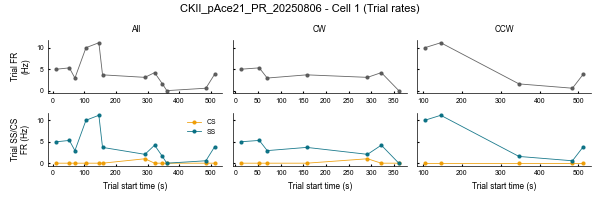

  [1/5] CKII_pAce21_PR_20250806 Cell 1
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_individual/CKII_pAce38_PX_20251126_Cell2_pf_centered.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_individual/CKII_pAce38_PX_20251126_Cell2_pf_centered_trials.svg


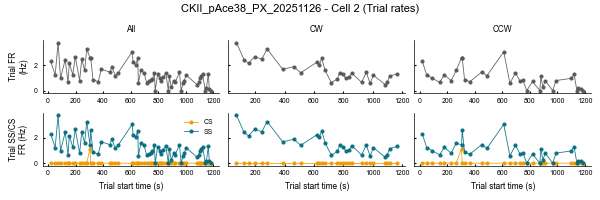

  [2/5] CKII_pAce38_PX_20251126 Cell 2
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_individual/CKII_pAce38_PX_20251126_Cell6_pf_centered.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_individual/CKII_pAce38_PX_20251126_Cell6_pf_centered_trials.svg


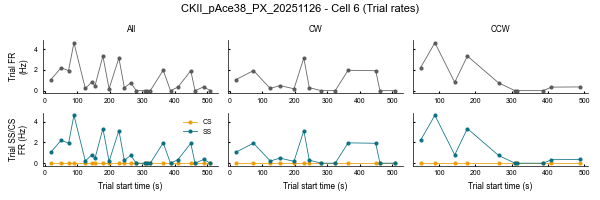

  [3/5] CKII_pAce38_PX_20251126 Cell 6
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_individual/CKII_pAce45_PX_20260118_Cell3_pf_centered.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_individual/CKII_pAce45_PX_20260118_Cell3_pf_centered_trials.svg


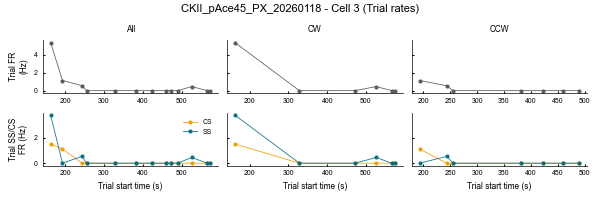

  [4/5] CKII_pAce45_PX_20260118 Cell 3
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_individual/CKII_pAce45_PX_20260118_Cell11_pf_centered.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_individual/CKII_pAce45_PX_20260118_Cell11_pf_centered_trials.svg


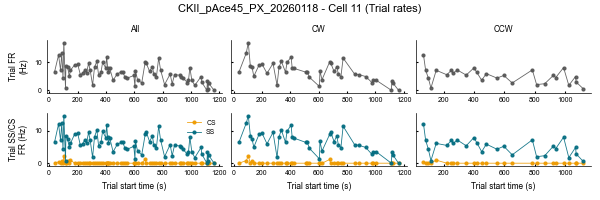

  [5/5] CKII_pAce45_PX_20260118 Cell 11

Saved individual CS- PLC plots to: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_individual


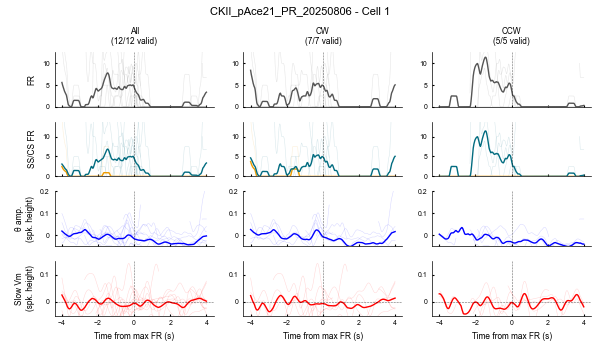

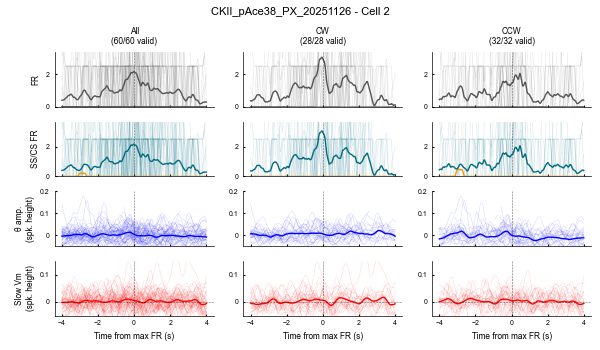

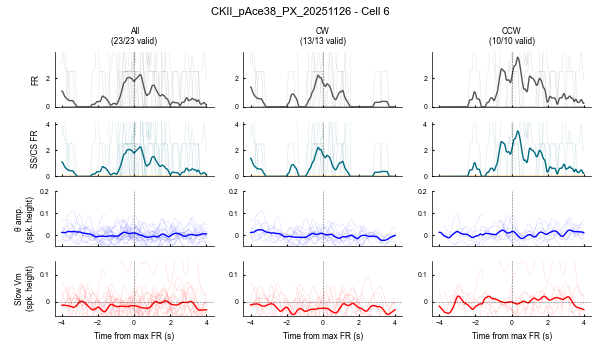

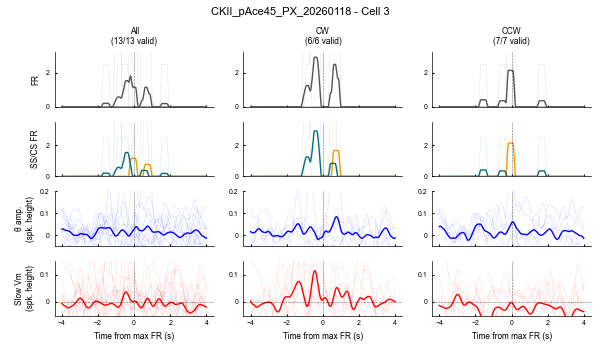

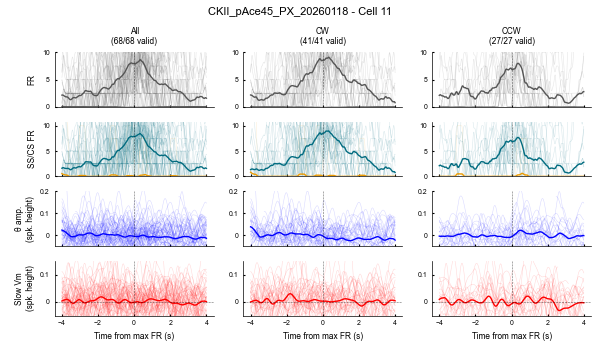

In [57]:
# ===================== CS- PLCs: Individual cell plots =====================
print(f"Plotting {len(cs_minus_entries)} CS- PLCs individual cell plots...")

cs_minus_save_folder = os.path.join(figure_save_folder, 'pf_centered_CSminus_individual')
os.makedirs(cs_minus_save_folder, exist_ok=True)

for i, entry_data in enumerate(cs_minus_entries):
    session = entry_data['session']
    cell_idx = entry_data['cell_idx']
    out_path = os.path.join(cs_minus_save_folder, f'{session}_Cell{cell_idx+1}_pf_centered.svg')
    
    plot_single_cell_3col(entry_data, time_rel_cs_minus, smooth_window=SMOOTH_WINDOW, plot_trials=PLOT_TRIALS,
                          trial_alpha=TRIAL_ALPHA, trial_linewidth=TRIAL_LINEWIDTH, out_path=out_path, show_plot=True,
                          theta_ylim=THETA_YLIM, slow_ylim=SLOW_YLIM,
                          fr_ylim_scale=FR_YLIM_SCALE, ss_cs_ylim_scale=SS_CS_YLIM_SCALE)
    print(f"  [{i+1}/{len(cs_minus_entries)}] {session} Cell {cell_idx+1}")

print(f"\nSaved individual CS- PLC plots to: {cs_minus_save_folder}")

Plotting 5 CS- PLCs individual cell heatmaps...


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_heatmaps/CKII_pAce21_PR_20250806_Cell1_heatmap.svg


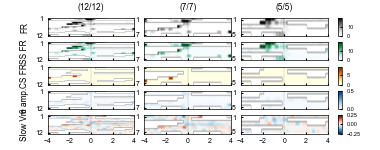

  [1/5] CKII_pAce21_PR_20250806 Cell 1


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_heatmaps/CKII_pAce38_PX_20251126_Cell2_heatmap.svg


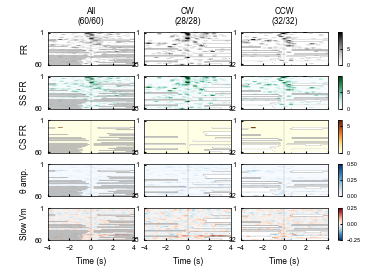

  [2/5] CKII_pAce38_PX_20251126 Cell 2


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_heatmaps/CKII_pAce38_PX_20251126_Cell6_heatmap.svg


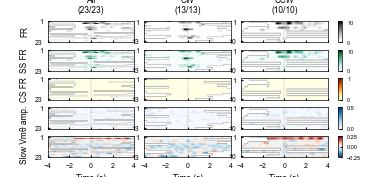

  [3/5] CKII_pAce38_PX_20251126 Cell 6


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_heatmaps/CKII_pAce45_PX_20260118_Cell3_heatmap.svg


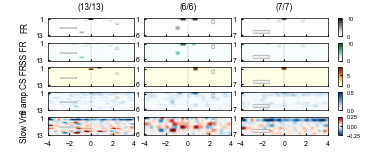

  [4/5] CKII_pAce45_PX_20260118 Cell 3


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_heatmaps/CKII_pAce45_PX_20260118_Cell11_heatmap.svg


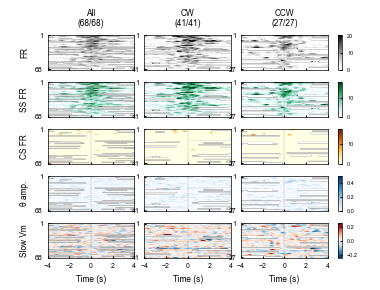

  [5/5] CKII_pAce45_PX_20260118 Cell 11

Saved individual CS- PLC heatmaps to: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_heatmaps


In [58]:
# ===================== CS- PLCs: Individual cell HEATMAP plots =====================
print(f"Plotting {len(cs_minus_entries)} CS- PLCs individual cell heatmaps...")

cs_minus_heatmap_folder = os.path.join(figure_save_folder, 'pf_centered_CSminus_heatmaps')
os.makedirs(cs_minus_heatmap_folder, exist_ok=True)

for i, entry_data in enumerate(cs_minus_entries):
    session = entry_data['session']
    cell_idx = entry_data['cell_idx']
    out_path = os.path.join(cs_minus_heatmap_folder, f'{session}_Cell{cell_idx+1}_heatmap.svg')
    
    plot_single_cell_heatmap(entry_data, time_rel_cs_minus, smooth_window=SMOOTH_WINDOW, 
                              out_path=out_path, show_plot=True,
                              fr_vmax_scale=0.6, theta_vlim=(0, 0.5), slow_vlim=(-0.25, 0.25),fig_width=3.8, trial_height=0.005, xlim=xlim)
    print(f"  [{i+1}/{len(cs_minus_entries)}] {session} Cell {cell_idx+1}")

print(f"\nSaved individual CS- PLC heatmaps to: {cs_minus_heatmap_folder}")

# Average plots for CS- PLCs

/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67261/629700795.py:558: RuntimeWarning: Mean of empty slice
  mean_arr = np.nanmean(arr, axis=0)


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/pf_centered_CSminus_average.svg


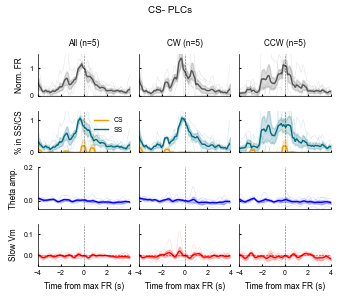

In [59]:
# ===================== CS- PLCs: Pooled average (3-column: All/CW/CCW) =====================
out_cs_minus = os.path.join(figure_save_folder, 'pf_centered_CSminus_average.svg')
plot_pooled_category_3col(time_rel_cs_minus, cs_minus_entries, 'CS- PLCs', out_cs_minus,
                          smooth_window=SMOOTH_WINDOW, plot_trials=PLOT_TRIALS,
                          trial_alpha=TRIAL_ALPHA, trial_linewidth=TRIAL_LINEWIDTH,
                          theta_ylim=THETA_YLIM, slow_ylim=SLOW_YLIM,
                          fr_ylim_scale=FR_YLIM_SCALE, ss_cs_ylim_scale=SS_CS_YLIM_SCALE, figsize=(3.4, 3), xlim=xlim)

CS+ reliability data: 24 entries
CS- reliability data: 15 entries

CS+ PLCs - Spike counts per cell
n_trials/n_total shows reliability.

CKII_pAce21_PR_20250806 Cell 4:
   ALL: 19 traversals | All: 15/19 (79%) | SS:  8/19 (42%) | CS: 13/19 (68%)
    CW: 13 traversals | All: 11/13 (85%) | SS:  6/13 (46%) | CS: 11/13 (85%)
   CCW:  6 traversals | All:  4/ 6 (67%) | SS:  2/ 6 (33%) | CS:  2/ 6 (33%)

CKII_pAce38_PX_20251126 Cell 1:
   ALL: 36 traversals | All: 36/36 (100%) | SS: 36/36 (100%) | CS: 28/36 (78%)
    CW: 15 traversals | All: 15/15 (100%) | SS: 15/15 (100%) | CS: 11/15 (73%)
   CCW: 21 traversals | All: 21/21 (100%) | SS: 21/21 (100%) | CS: 17/21 (81%)

CKII_pAce38_PX_20251126 Cell 3:
   ALL: 45 traversals | All: 43/45 (96%) | SS: 43/45 (96%) | CS: 34/45 (76%)
    CW: 20 traversals | All: 19/20 (95%) | SS: 19/20 (95%) | CS: 17/20 (85%)
   CCW: 25 traversals | All: 24/25 (96%) | SS: 24/25 (96%) | CS: 17/25 (68%)

CKII_pAce38_PX_20251126 Cell 4:
   ALL: 30 traversals | All: 30/3

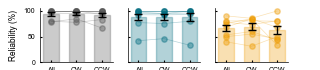

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/reliability_CSminus.svg


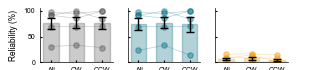

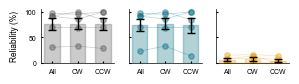

In [60]:
# ===================== Reliability Analysis =====================
# Calculate reliability (percentage of trials with non-zero spiking) for each cell

def calculate_reliability(entries, category_name):
    """Calculate reliability for each cell and traversal type.
    
    Uses pre-computed reliability values from saved data:
    - All spikes: n_reliable_trials / n_total_trials (trials with ≥1 spike in PF)
    - SS: (trials with SS spikes in PF) / n_total_trials
    - CS: (trials with CS spikes in PF) / n_total_trials
    
    Spike counts are from trial_data which counts spikes WITHIN the place field traversal.
    """
    results = []
    
    for entry_data in entries:
        session = entry_data['session']
        cell_idx = entry_data['cell_idx']
        cell_data = entry_data.get('data')
        
        if cell_data is None:
            continue
        
        for direction in ['all', 'cw', 'ccw']:
            dir_data = cell_data.get(direction, {})
            
            if not dir_data:
                continue
            
            n_trials = dir_data.get('n_trials', 0)
            n_total_trials = dir_data.get('n_total_trials', 0)
            
            if n_total_trials == 0:
                continue
            
            # Use pre-computed reliability for all spikes
            n_reliable = dir_data.get('n_reliable_trials', n_trials)
            rel_all = dir_data.get('reliability', n_reliable / n_total_trials if n_total_trials > 0 else 0)
            rel_all = rel_all * 100  # Convert to percentage
            
            # Get trial_data for SS/CS spike counts within PF
            trial_data = dir_data.get('trial_data', {})
            n_spikes_ss = trial_data.get('n_spikes_ss', None)
            n_spikes_cs = trial_data.get('n_spikes_cs', None)
            
            # SS reliability: count trials with ≥1 SS spike in PF
            if n_spikes_ss is not None:
                n_spikes_ss = np.asarray(n_spikes_ss)
                n_with_ss = int(np.sum(n_spikes_ss > 0))
                rel_ss = (n_with_ss / n_total_trials) * 100
            else:
                n_with_ss = 0
                rel_ss = 0.0
            
            # CS reliability: count trials with ≥1 CS spike in PF
            if n_spikes_cs is not None:
                n_spikes_cs = np.asarray(n_spikes_cs)
                n_with_cs = int(np.sum(n_spikes_cs > 0))
                rel_cs = (n_with_cs / n_total_trials) * 100
            else:
                n_with_cs = 0
                rel_cs = 0.0
            
            results.append({
                'session': session,
                'cell_idx': cell_idx,
                'category': category_name,
                'direction': direction,
                'reliability_all': rel_all,
                'reliability_ss': rel_ss,
                'reliability_cs': rel_cs,
                'n_reliable_trials': n_reliable,
                'n_with_ss': n_with_ss,
                'n_with_cs': n_with_cs,
                'n_trials': n_trials,
                'n_total_trials': n_total_trials,
            })
    
    return pd.DataFrame(results)

# Calculate reliability for CS+ and CS- PLCs
df_rel_csplus = calculate_reliability(cs_plus_entries, 'CS+')
df_rel_csminus = calculate_reliability(cs_minus_entries, 'CS-')

print(f"CS+ reliability data: {len(df_rel_csplus)} entries")
print(f"CS- reliability data: {len(df_rel_csminus)} entries")

# ===================== Print detailed spike counts per cell =====================
def print_spike_counts(entries, category_name):
    """Print detailed spike counts for each cell."""
    print(f"\n{'='*80}")
    print(f"{category_name} PLCs - Spike counts per cell")
    print(f"n_trials/n_total shows reliability.")
    print(f"{'='*80}")
    
    for entry_data in entries:
        session = entry_data['session']
        cell_idx = entry_data['cell_idx']
        cell_data = entry_data.get('data')
        
        if cell_data is None:
            print(f"{session} Cell {cell_idx+1}: No data")
            continue
        
        print(f"\n{session} Cell {cell_idx+1}:")
        
        for direction in ['all', 'cw', 'ccw']:
            dir_data = cell_data.get(direction, {})
            
            if not dir_data:
                print(f"  {direction.upper():>4}: No data")
                continue
            
            n_trials = dir_data.get('n_trials', 0)
            n_total = dir_data.get('n_total_trials', 0)
            
            if n_total == 0:
                print(f"  {direction.upper():>4}: No traversals")
                continue
            
            ss_rate_stack = dir_data.get('ss_rate_stack')
            cs_rate_stack = dir_data.get('cs_rate_stack')
            
            # Use pre-computed reliability and spike counts from trial_data
            n_reliable = dir_data.get('n_reliable_trials', n_trials)
            trial_data = dir_data.get('trial_data', {})
            n_spikes_ss = trial_data.get('n_spikes_ss', None)
            n_spikes_cs = trial_data.get('n_spikes_cs', None)
            
            n_with_ss = int(np.sum(np.asarray(n_spikes_ss) > 0)) if n_spikes_ss is not None else 0
            n_with_cs = int(np.sum(np.asarray(n_spikes_cs) > 0)) if n_spikes_cs is not None else 0
            
            rel_all = 100 * n_reliable / n_total if n_total > 0 else 0
            rel_ss = 100 * n_with_ss / n_total if n_total > 0 else 0
            rel_cs = 100 * n_with_cs / n_total if n_total > 0 else 0
            
            print(f"  {direction.upper():>4}: {n_total:2d} traversals | "
                  f"All: {n_reliable:2d}/{n_total:2d} ({rel_all:.0f}%) | "
                  f"SS: {n_with_ss:2d}/{n_total:2d} ({rel_ss:.0f}%) | "
                  f"CS: {n_with_cs:2d}/{n_total:2d} ({rel_cs:.0f}%)")

print_spike_counts(cs_plus_entries, 'CS+')
print_spike_counts(cs_minus_entries, 'CS-')

# ===================== Plot Reliability =====================

def plot_reliability_scatter_bar(df_rel, category_name, out_path=None):
    """Plot reliability: scatter for each cell connected by lines, with bar plot overlay."""
    
    if len(df_rel) == 0:
        print(f"No data for {category_name}")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(3.2, 0.7), sharey=True)
    
    spike_types = ['all', 'ss', 'cs']
    spike_labels = ['All Spikes', 'SS', 'CS']
    spike_colors = ['#555555', '#026C80', '#EE9B00']
    
    directions = ['all', 'cw', 'ccw']
    dir_labels = ['All', 'CW', 'CCW']
    x_positions = np.array([0, 1, 2])
    
    for ax_idx, (spike_type, spike_label, spike_color) in enumerate(zip(spike_types, spike_labels, spike_colors)):
        ax = axes[ax_idx]
        
        # Get unique cells
        cell_ids = df_rel[['session', 'cell_idx']].drop_duplicates()
        
        # Collect data for bar plot
        all_values = {d: [] for d in directions}
        
        # Plot individual cells
        for _, cell_row in cell_ids.iterrows():
            cell_data = df_rel[(df_rel['session'] == cell_row['session']) & 
                               (df_rel['cell_idx'] == cell_row['cell_idx'])]
            
            y_vals = []
            x_vals = []
            for i, direction in enumerate(directions):
                dir_data = cell_data[cell_data['direction'] == direction]
                if len(dir_data) > 0:
                    val = dir_data[f'reliability_{spike_type}'].values[0]
                    if not np.isnan(val):
                        y_vals.append(val)
                        x_vals.append(x_positions[i])
                        all_values[direction].append(val)
            
            # Plot scatter and connecting lines
            if len(x_vals) > 0:
                ax.scatter(x_vals, y_vals, color=spike_color, s=15, alpha=0.4, zorder=2)
                if len(x_vals) > 1:
                    ax.plot(x_vals, y_vals, color=spike_color, linewidth=0.5, alpha=0.3, zorder=1)
        
        # Calculate means and SEMs for bar plot
        means = []
        sems = []
        for direction in directions:
            vals = np.array(all_values[direction])
            if len(vals) > 0:
                means.append(np.nanmean(vals))
                sems.append(np.nanstd(vals) / np.sqrt(len(vals)))
            else:
                means.append(0)
                sems.append(0)
        
        # Plot bar with error bars
        ax.bar(x_positions, means, width=0.6, color=spike_color, alpha=0.3, edgecolor=spike_color, linewidth=1, zorder=0)
        ax.errorbar(x_positions, means, yerr=sems, fmt='none', color='black', capsize=3, linewidth=1, zorder=3)
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(dir_labels)
        #ax.set_title(spike_label, fontsize=8)
        ax.set_ylim(0, 105)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add n for each direction
        for i, direction in enumerate(directions):
            n = len(all_values[direction])
            ax.text(x_positions[i], -6, f'', ha='center', fontsize=5)
    
    axes[0].set_ylabel('Reliability (%)', fontsize=6)
    
    #fig.suptitle(f'{category_name} PLCs - Reliability\n(% trials with non-zero spiking)', fontsize=9)
    #plt.tight_layout(rect=[0, 0.02, 1, 0.92])
    
    if out_path is not None:
        fig.savefig(out_path, dpi=300)
        print(f'Saved: {out_path}')
    
    plt.show()
    return fig

# Plot for CS+ PLCs
out_rel_csplus = os.path.join(figure_save_folder, 'reliability_CSplus.svg')
plot_reliability_scatter_bar(df_rel_csplus, 'CS+', out_rel_csplus)

# Plot for CS- PLCs
out_rel_csminus = os.path.join(figure_save_folder, 'reliability_CSminus.svg')
plot_reliability_scatter_bar(df_rel_csminus, 'CS-', out_rel_csminus)